In [8]:
!pip install -U langgraph langchain-groq langchain-community tavily-python
!pip install arxiv

In [9]:
import os
from typing import Annotated, TypedDict, List, Dict, Any
from typing_extensions import Literal

# GROQ and LangChain Imports
from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities import ArxivAPIWrapper
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import StateGraph, START, END
from google.colab import userdata

In [11]:
try:
    os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
    os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')
    print("Groq client initialized successfully.")
except Exception as e:
    print(f"Error initializing Groq client. Make sure your API key is set correctly. Error: {e}")
    client = None

Groq client initialized successfully.


In [12]:
class AgentState(TypedDict):
    """The state of the research assistant."""
    messages: Annotated[list[BaseMessage], lambda x, y: x + y]
    domain: str
    basic_problem: str
    research_gaps: List[str]
    paper_draft: Dict[str, str]
    next_step: str

# --- 2. AGENT INITIALIZATION (GROQ) ---

# Using Llama 3 70B for high-quality reasoning, or 8B for extreme speed
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.1,
    max_retries=2
)
search_tool = TavilySearchResults(max_results=3)
arxiv_tool = ArxivAPIWrapper()

def create_agent(llm, tools, system_prompt: str):
    """Helper to bind tools and system prompts to the GROQ model."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
    ])
    if tools:
        return prompt | llm.bind_tools(tools)
    return prompt | llm

/tmp/ipykernel_641/2303213336.py:18: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=3)


In [13]:
# --- 3. NODE DEFINITIONS ---

def explorer_node(state: AgentState):
    """Searches for relevant papers using Tavily and ArXiv."""
    explorer_prompt = f"""You are the SBU Search Specialist using GROQ speed.
    Domain: {state['domain']}
    Current Problem: {state['basic_problem']}

    Task: Find the 3 most relevant current papers.
    Focus on specific methodologies and architectural trends."""

    agent = create_agent(llm, [search_tool], explorer_prompt)
    response = agent.invoke(state)
    return {"messages": [response], "next_step": "reviewer"}

def reviewer_node(state: AgentState):
    """Identifies research gaps in the gathered data."""
    reviewer_prompt = f"""You are the Literature Reviewer.
    Analyze gathered info and identify 3 'Research Gaps'.
    What is missing in {state['domain']} regarding {state['basic_problem']}?"""

    agent = create_agent(llm, None, reviewer_prompt)
    response = agent.invoke(state)

    gaps = [line for line in response.content.split('\n') if 'gap' in line.lower()][:3]

    return {
        "messages": [response],
        "research_gaps": gaps,
        "next_step": "writer"
    }

def writer_node(state: AgentState):
    """Drafts formal paper sections based on the gaps."""
    writer_prompt = f"""You are the Academic Paper Architect.
    Gaps: {state['research_gaps']}
    Draft: Abstract, Intro, Methodology, Proposed Arch, and Conclusion.
    Tone: Formal Academic."""

    agent = create_agent(llm, None, writer_prompt)
    response = agent.invoke(state)

    return {
        "messages": [response],
        "paper_draft": {"full_report": response.content},
        "next_step": "end"
    }

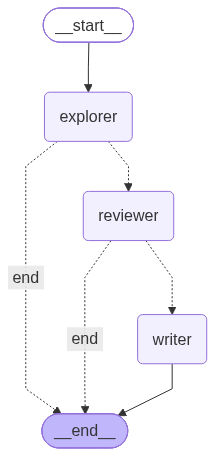

In [14]:
# --- 4. GRAPH CONSTRUCTION ---

def router(state: AgentState):
    return state["next_step"]

workflow = StateGraph(AgentState)

workflow.add_node("explorer", explorer_node)
workflow.add_node("reviewer", reviewer_node)
workflow.add_node("writer", writer_node)

workflow.add_edge(START, "explorer")
workflow.add_conditional_edges("explorer", router, {"reviewer": "reviewer", "end": END})
workflow.add_conditional_edges("reviewer", router, {"writer": "writer", "end": END})
workflow.add_edge("writer", END)

app = workflow.compile()
app

In [15]:
# --- 5. EXECUTION ---
if __name__ == "__main__":
    initial_input = {
        "domain": "Sustainable Energy AI",
        "basic_problem": "Predicting micro-grid stability with high intermittent renewable penetration",
        "messages": [HumanMessage(content="Analyze micro-grid stability research.")],
        "research_gaps": [],
        "paper_draft": {},
        "next_step": ""
    }
    print("⚡ Starting GROQ-powered Research Explorer...")
    for output in app.stream(initial_input):
        for key, value in output.items():
            print(f"\n--- [Node: {key}] ---")
            if 'messages' in value:
                print(value['messages'][-1].content[:] + "...")

⚡ Starting GROQ-powered Research Explorer...

--- [Node: explorer] ---
...

--- [Node: reviewer] ---
 
Based on the gathered information, here's an analysis of the current state of micro-grid stability research, focusing on predicting micro-grid stability with high intermittent renewable penetration:

**Current State:**

1. **Renewable Energy Integration:** Researchers have made significant progress in integrating renewable energy sources, such as solar and wind power, into micro-grids. However, the intermittent nature of these sources poses challenges to micro-grid stability.
2. **Predictive Modeling:** Various predictive models, including machine learning and deep learning techniques, have been developed to forecast renewable energy output and predict micro-grid stability. These models often rely on historical data, weather forecasts, and other factors to make predictions.
3. **Control Strategies:** Researchers have proposed various control strategies to maintain micro-grid stability